# Torpedo Firing Doctrine Comparison

This notebook compares focused, submarine-centric snapshots for three fan-mode firing doctrines:

- `longitudinal`: no final gyro divergence; apparent spread comes from launch timing and submarine motion.
- `uniform_divergent`: evenly spaced final gyro offsets across a total `spread_rad`.
- `explicit_divergent`: authored per-torpedo final gyro offsets.

Structure:
- one large plot cell per doctrine / motion case
- the snapshot is taken at the end of the firing cycle plus a short post-launch window
- a compact text table is printed under each plot with launch positions, launch times, and final headings
- short markdown note cells are provided after the paired cases so you can record observations after running the notebook

This notebook intentionally uses a faint vertical centerline reference instead of plotting a convoy centroid or target marker.

Plot convention:
- The U-boat is shown at a common end-of-firing-cycle snapshot.
- Torpedo paths are drawn out to their full post-launch run endurance so salvo members keep equal total range.


In [1]:
#Imports
from __future__ import annotations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from convoy_sim.attack_profiles import AttackProfile
from convoy_sim.realism import UBoatMotionPlan
from convoy_sim.viz_attack import (format_torpedo_heading_table, plot_torpedo_doctrine_snapshot, sample_u_boat_track,)

plt.rcParams["figure.facecolor"] = "lightgrey"
plt.rcParams["axes.facecolor"] = "#06768d"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 11



In [2]:
BASE_BEARING_RAD = float(np.pi / 2.0)
U_BOAT_START = np.array([0.0, -260.0], dtype=float)
U_BOAT_SPEED_MPS = 3.0
SALVO_INTERVAL_S = 4.0
POST_FIRE_WINDOW_S = 18.0
VIEW_BOUNDS = (-150.0, 150.0, -250.0, 300.0)
UNIFORM_SPREAD_RAD = float(np.deg2rad(18.0))
EXPLICIT_OFFSETS_RAD = tuple(np.deg2rad(np.array([-12.0, -3.0, 2.0, 10.0], dtype=float)))

DOCTRINE_TITLES = {
    "longitudinal": "Longitudinal / Timing-Only",
    "uniform_divergent": "Uniform Divergent",
    "explicit_divergent": "Explicit Divergent",
}


def _motion_payload(profile: AttackProfile) -> dict[str, object]:
    initial_heading = float(profile.u_boat_initial_heading_rad)
    if profile.uses_legacy_bearing_compat():
        initial_heading = float(profile.requested_attack_bearing_rad())
    return {
        "mode": profile.u_boat_mode,
        "initial_position": [float(profile.u_pos[0]), float(profile.u_pos[1])],
        "initial_heading_rad": initial_heading,
        "initial_speed_mps": float(profile.u_boat_initial_speed_mps),
        "launch_time_s": float(profile.u_boat_launch_time_s),
        "turn_rate_limit_rad_s": profile.u_boat_turn_rate_limit_rad_s,
        "accel_limit_mps2": profile.u_boat_accel_limit_mps2,
        "legs": [
            {"duration_s": float(a), "heading_rad": float(b), "speed_mps": float(c)}
            for (a, b, c) in profile.u_boat_motion_legs
        ],
    }


def build_profile(doctrine: str, *, moving: bool) -> AttackProfile:
    kwargs: dict[str, object] = {
        "profile_id": f"{doctrine[:3].upper()}_{'MOV' if moving else 'STA'}",
        "name": f"{doctrine}_{'moving' if moving else 'static'}",
        "mode": "fan",
        "u_pos": tuple(U_BOAT_START),
        "n": 4,
        "speed": 15.4333,
        "max_run_time": 160.0,
        "base_bearing_rad": BASE_BEARING_RAD,
        "spread_rad": 0.0 if doctrine == "longitudinal" else UNIFORM_SPREAD_RAD,
        "spread_doctrine": doctrine,
        "launch_delay_s": 0.0,
        "salvo_interval_s": SALVO_INTERVAL_S,
        "u_boat_mode": "moving" if moving else "static",
        "u_boat_initial_heading_rad": BASE_BEARING_RAD,
        "u_boat_initial_speed_mps": U_BOAT_SPEED_MPS,
        "u_boat_launch_time_s": 0.0,
        "launch_from": "bow",
        "max_bow_offset_deg": 20.0,
        "gyro_straight_run_m": 30.0,
        "require_stable_u_boat_during_salvo": True,
    }
    if moving:
        kwargs["u_boat_motion_legs"] = ((120.0, BASE_BEARING_RAD, U_BOAT_SPEED_MPS),)
    if doctrine == "explicit_divergent":
        kwargs["spread_rad"] = 0.0
        kwargs["per_torpedo_heading_offsets_rad"] = EXPLICIT_OFFSETS_RAD
    return AttackProfile(**kwargs)


def motion_plan_for_profile(profile: AttackProfile) -> UBoatMotionPlan:
    return UBoatMotionPlan.from_dict(_motion_payload(profile), fallback_u_pos=profile.u_pos)


def snapshot_time_for_profile(profile: AttackProfile) -> float:
    last_launch = float(profile.u_boat_launch_time_s + profile.launch_delay_s + (profile.n - 1) * profile.salvo_interval_s)
    return last_launch + POST_FIRE_WINDOW_S


def show_case(doctrine: str, *, moving: bool) -> tuple[AttackProfile, list]:
    profile = build_profile(doctrine, moving=moving)
    torpedoes = profile.build_torpedoes(np.random.default_rng(7))
    motion_plan = motion_plan_for_profile(profile)
    snapshot_time = snapshot_time_for_profile(profile)
    u_pos, u_heading, _ = motion_plan.state_at(snapshot_time)
    u_track = None
    if moving:
        u_track = sample_u_boat_track(motion_plan, 0.0, snapshot_time, n_points=200)

    fig, ax = plt.subplots(figsize=(8.2, 8.6), facecolor="lightgrey")
    plot_torpedo_doctrine_snapshot(
        torpedoes,
        snapshot_time_s=snapshot_time,
        ax=ax,
        title=f"{DOCTRINE_TITLES[doctrine]} | {'Moving' if moving else 'Static'} U-boat",
        u_boat_track=u_track,
        u_boat_position=np.asarray(u_pos, dtype=float),
        u_boat_heading_rad=float(u_heading),
        centerline_bearing_rad=BASE_BEARING_RAD,
        show_centerline=False,
        view_bounds=VIEW_BOUNDS,
        figure_facecolor="lightgrey",
        axes_facecolor="#06768d",
        torpedo_linewidth=1.0,
        show_full_torpedo_run=True,
    )
    plt.show()

    print(f"Snapshot time: {snapshot_time:.1f}s")
    print(format_torpedo_heading_table(torpedoes))
    return profile, torpedoes


def show_summary_grid() -> None:
    order = [
        ("longitudinal", False),
        ("longitudinal", True),
        ("uniform_divergent", False),
        ("uniform_divergent", True),
        ("explicit_divergent", False),
        ("explicit_divergent", True),
    ]
    fig, axes = plt.subplots(3, 2, figsize=(12.5, 17.5), facecolor="lightgrey")
    for ax, (doctrine, moving) in zip(axes.flat, order):
        profile = build_profile(doctrine, moving=moving)
        torpedoes = profile.build_torpedoes(np.random.default_rng(7))
        motion_plan = motion_plan_for_profile(profile)
        snapshot_time = snapshot_time_for_profile(profile)
        u_pos, u_heading, _ = motion_plan.state_at(snapshot_time)
        u_track = sample_u_boat_track(motion_plan, 0.0, snapshot_time, n_points=200) if moving else None
        plot_torpedo_doctrine_snapshot(
            torpedoes,
            snapshot_time_s=snapshot_time,
            ax=ax,
            title=f"{DOCTRINE_TITLES[doctrine]} | {'Moving' if moving else 'Static'}",
            u_boat_track=u_track,
            u_boat_position=np.asarray(u_pos, dtype=float),
            u_boat_heading_rad=float(u_heading),
            centerline_bearing_rad=BASE_BEARING_RAD,
        show_centerline=False,
            view_bounds=VIEW_BOUNDS,
            axes_facecolor="#06768d",
            torpedo_linewidth=1.0,
            show_full_torpedo_run=True,
        )
    fig.tight_layout()
    plt.show()


## Longitudinal Doctrine

Interpretation focus:
- Static case: all visual separation should come from launch timing after the torpedoes leave the bow.
- Moving case: launch origins should march upward with the boat while the final headings remain aligned.


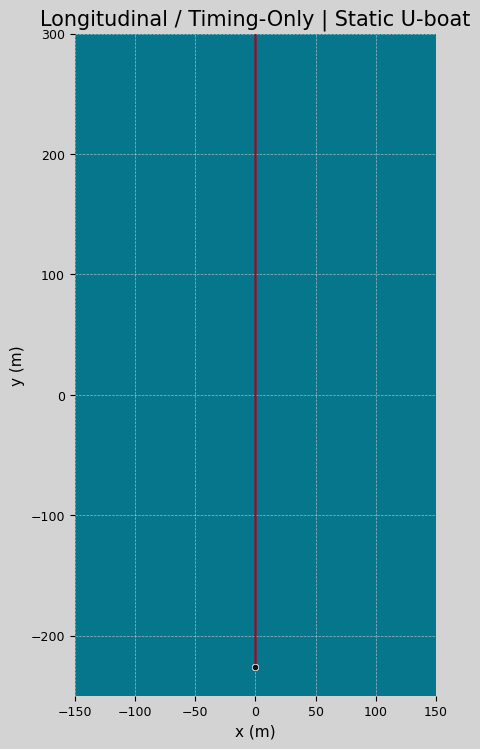

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       90.0       0.0
   2   F02        4.0         0.0      -226.5        90.0       90.0       0.0
   3   F03        8.0         0.0      -226.5        90.0       90.0       0.0
   4   F04       12.0         0.0      -226.5        90.0       90.0       0.0


In [3]:
profile_long_static, torps_long_static = show_case('longitudinal', moving=False)


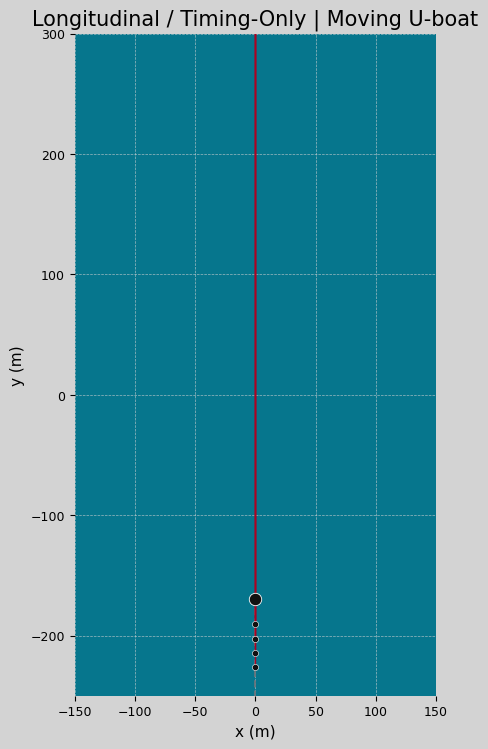

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       90.0       0.0
   2   F02        4.0         0.0      -214.5        90.0       90.0       0.0
   3   F03        8.0         0.0      -202.5        90.0       90.0       0.0
   4   F04       12.0         0.0      -190.5        90.0       90.0       0.0


In [4]:
profile_long_moving, torps_long_moving = show_case('longitudinal', moving=True)


### Longitudinal Notes

After running the two cells above, note:
- How much of the apparent spread comes from launch timing alone?
- How much additional separation is created by the moving U-boat's changing launch origin?


## Uniform Divergent Doctrine

Interpretation focus:
- Compare this against the longitudinal case with the same timing and boat motion.
- The final headings should form a symmetric fan around the vertical centerline.


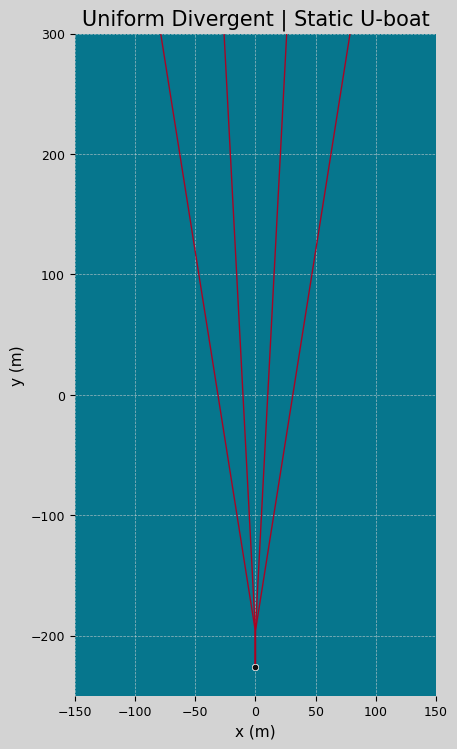

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       81.0      -9.0
   2   F02        4.0         0.0      -226.5        90.0       87.0      -3.0
   3   F03        8.0         0.0      -226.5        90.0       93.0       3.0
   4   F04       12.0         0.0      -226.5        90.0       99.0       9.0


In [5]:
profile_uniform_static, torps_uniform_static = show_case('uniform_divergent', moving=False)


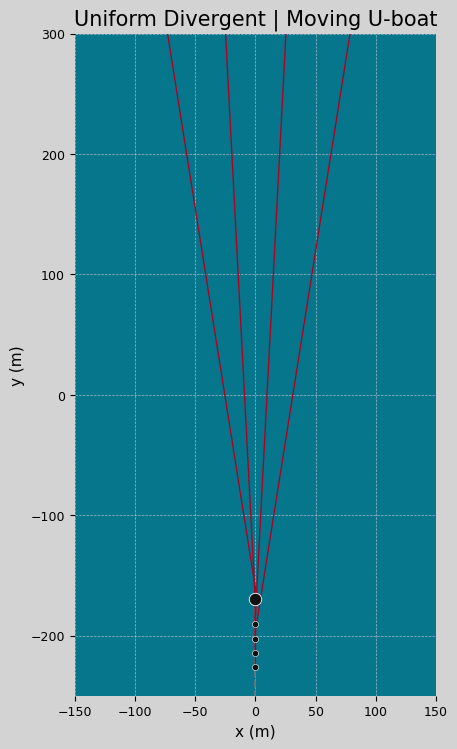

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       81.0      -9.0
   2   F02        4.0         0.0      -214.5        90.0       87.0      -3.0
   3   F03        8.0         0.0      -202.5        90.0       93.0       3.0
   4   F04       12.0         0.0      -190.5        90.0       99.0       9.0


In [6]:
profile_uniform_moving, torps_uniform_moving = show_case('uniform_divergent', moving=True)


### Uniform Divergent Notes

After running the two cells above, note:
- Whether the torpedo tracks stay symmetric around the centerline.
- Whether U-boat motion changes only the launch geometry or also the readability of the fan.


## Explicit Divergent Doctrine

Interpretation focus:
- This case uses authored, non-uniform per-torpedo offsets.
- The visual fan should be asymmetric relative to the vertical centerline.


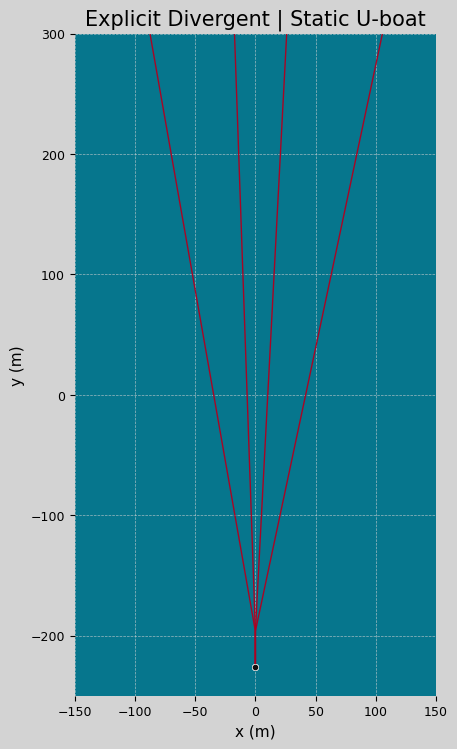

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       78.0     -12.0
   2   F02        4.0         0.0      -226.5        90.0       87.0      -3.0
   3   F03        8.0         0.0      -226.5        90.0       92.0       2.0
   4   F04       12.0         0.0      -226.5        90.0      100.0      10.0


In [7]:
profile_explicit_static, torps_explicit_static = show_case('explicit_divergent', moving=False)


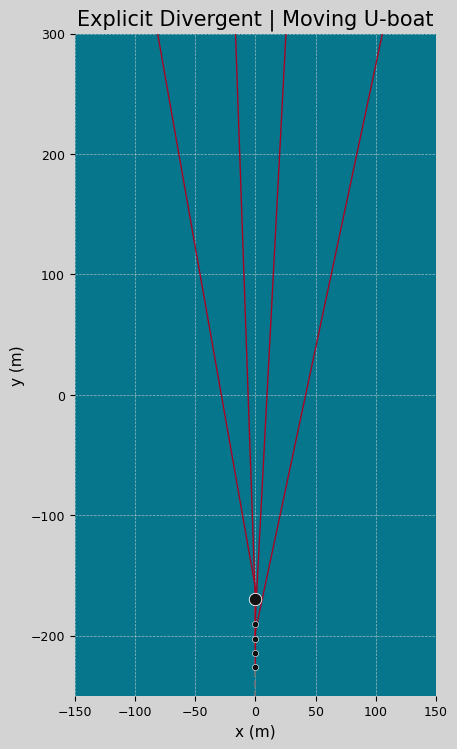

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0      -226.5        90.0       78.0     -12.0
   2   F02        4.0         0.0      -214.5        90.0       87.0      -3.0
   3   F03        8.0         0.0      -202.5        90.0       92.0       2.0
   4   F04       12.0         0.0      -190.5        90.0      100.0      10.0


In [8]:
profile_explicit_moving, torps_explicit_moving = show_case('explicit_divergent', moving=True)


### Explicit Divergent Notes

After running the two cells above, note:
- Which offsets dominate the visible spread shape.
- Whether the non-uniform spacing is still legible once the U-boat is moving.


## Cross-Doctrine Notes

After running all six cases, compare:
- Same doctrine, static vs moving: what changed because of motion alone?
- Same boat motion, different doctrines: what changed because of doctrine alone?
- Which doctrine is easiest to interpret visually and which is most useful for validation?


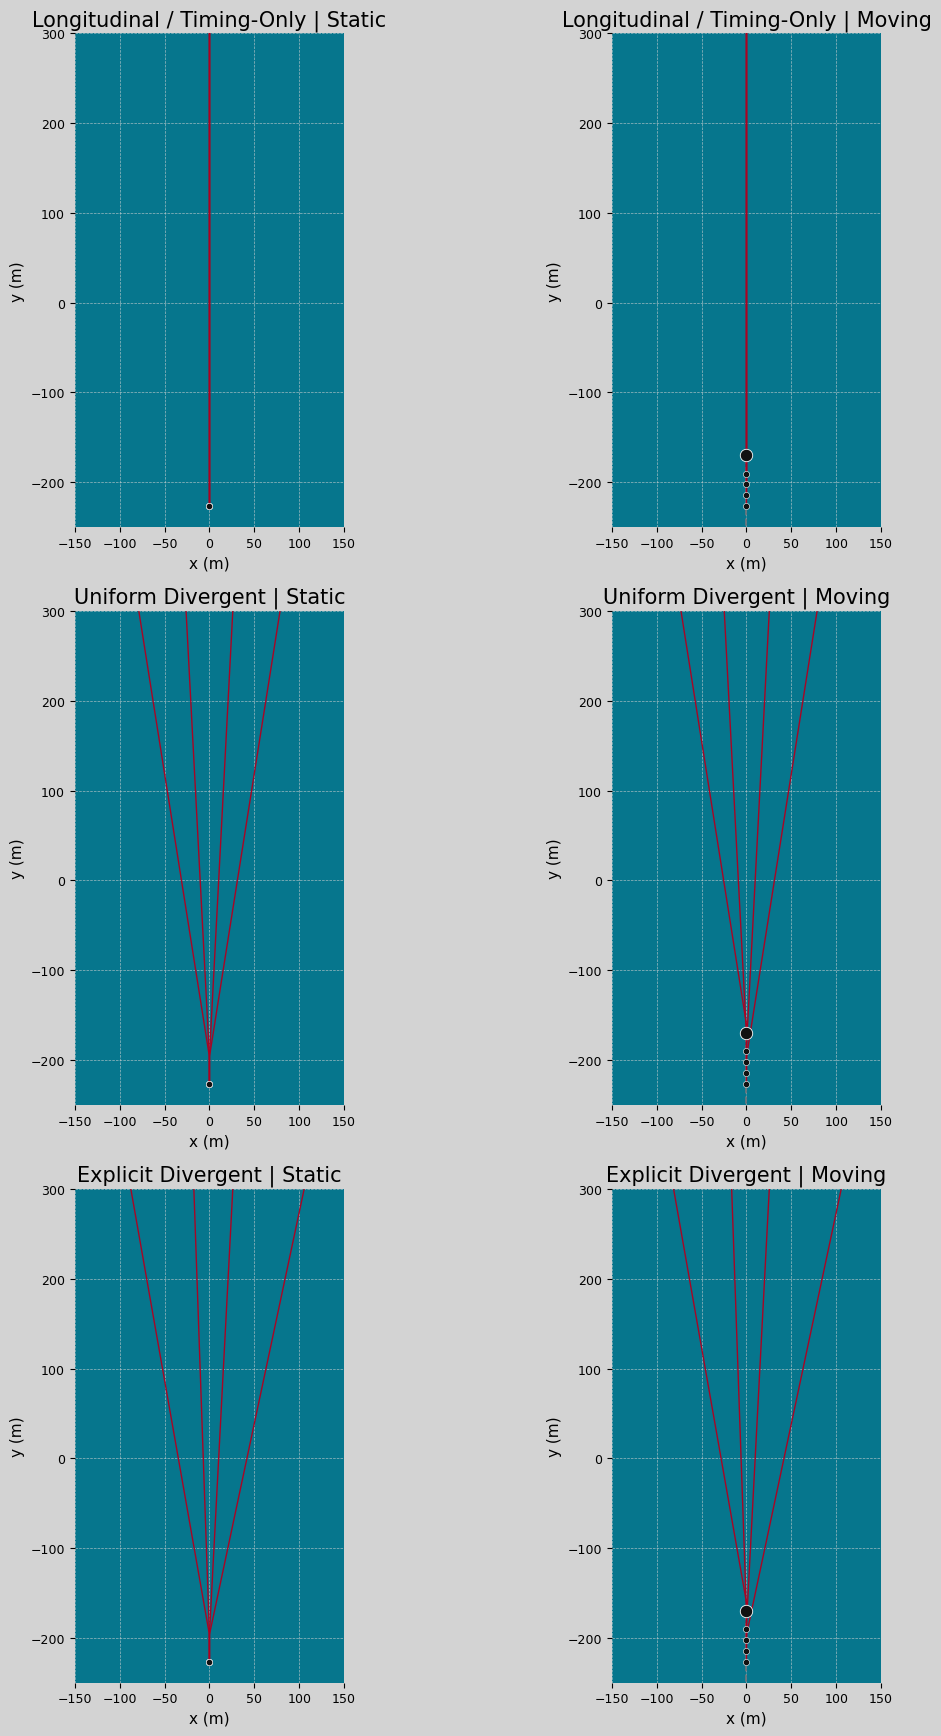

In [9]:
show_summary_grid()
